In [4]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load
import time
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
import seaborn as sns
import optuna
import math
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import GridSearchCV, cross_val_score, train_test_split
from sklearn.linear_model import LinearRegression, Lasso
from sklearn.ensemble import RandomForestRegressor
from sklearn.feature_selection import RFECV
from sklearn.metrics import mean_absolute_error, mean_squared_error, make_scorer, r2_score

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/sunspots/Sunspots.csv
/kaggle/input/electric-power-consumption-data-set/household_power_consumption.txt


In [5]:
!pip install optuna --quiet

# Dataset

## Electricity

In [6]:
df_el = pd.read_csv('../input/electric-power-consumption-data-set/household_power_consumption.txt', sep=';', 
                 parse_dates={'dt' : ['Date', 'Time']}, infer_datetime_format=True, 
                 low_memory=False, na_values=['nan','?'], index_col='dt')

df_el = df_el.apply(pd.to_numeric, errors='coerce').fillna(method='ffill')

df_el = df_el[['Global_active_power']].dropna()

df_el = df_el.resample('h').mean()

<ipython-input-6-273e62eb40b3>:1: FutureWarning: Support for nested sequences for 'parse_dates' in pd.read_csv is deprecated. Combine the desired columns with pd.to_datetime after parsing instead.
  df_el = pd.read_csv('../input/electric-power-consumption-data-set/household_power_consumption.txt', sep=';',
<ipython-input-6-273e62eb40b3>:1: FutureWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  df_el = pd.read_csv('../input/electric-power-consumption-data-set/household_power_consumption.txt', sep=';',
<ipython-input-6-273e62eb40b3>:1: UserWarning: Parsing dates in %d/%m/%Y %H:%M:%S format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df_el = pd.read_csv('../input/electric-power-consumption-data-set/household_

In [4]:
df_el.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 34589 entries, 2006-12-16 17:00:00 to 2010-11-26 21:00:00
Freq: h
Data columns (total 1 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Global_active_power  34589 non-null  float64
dtypes: float64(1)
memory usage: 540.5 KB


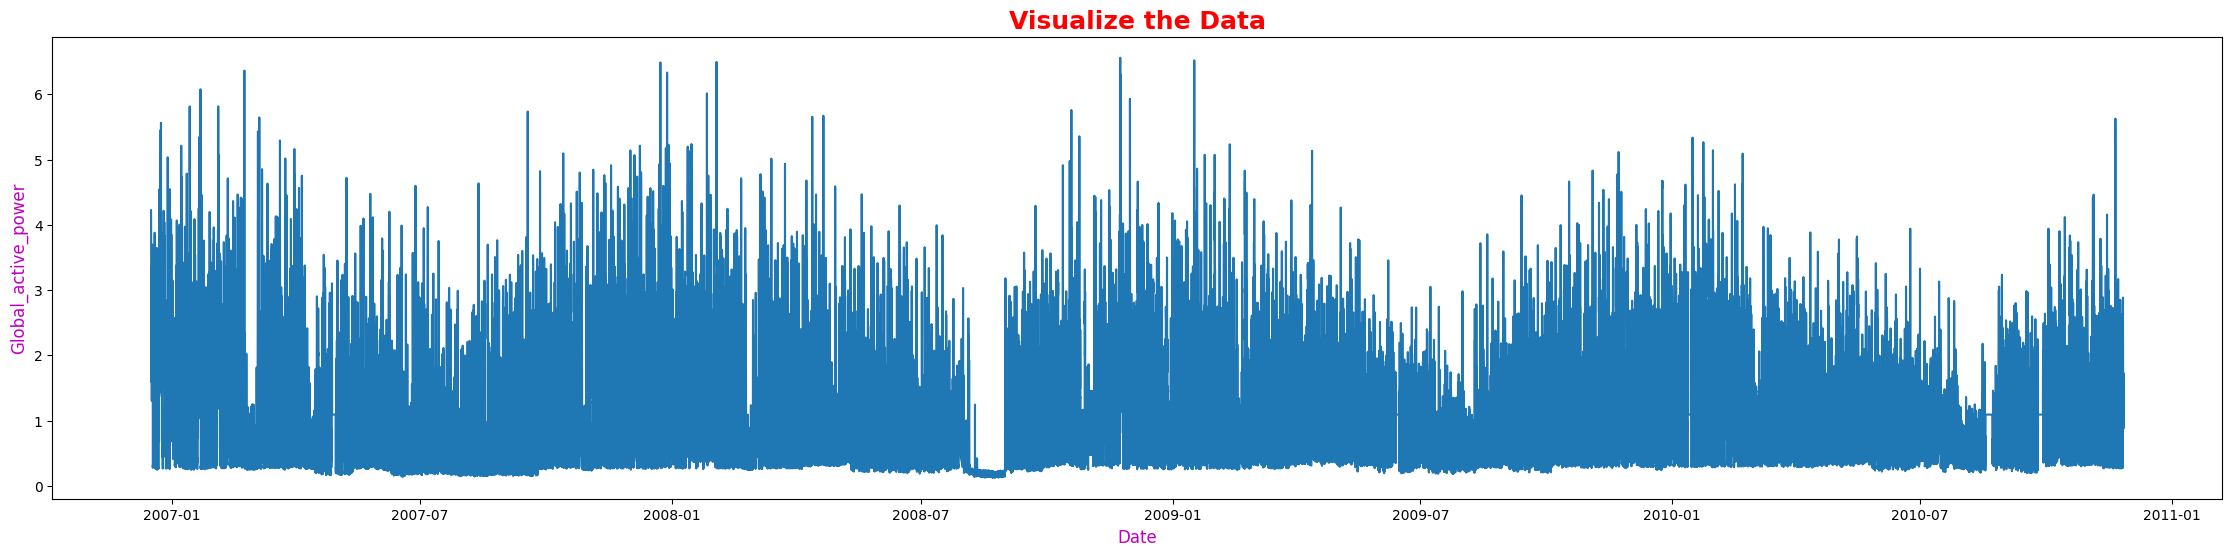

In [5]:
plt.figure(figsize=(28,6))
plt.plot(df_el)
plt.ylabel(df_el.columns[-1], fontsize = 12, color = 'm')
plt.xlabel("Date", fontsize = 12, color = 'm')
plt.title("Visualize the Data", fontsize = 18, color = 'r', weight = 'bold')
plt.show()

/usr/local/lib/python3.10/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.10/dist-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/usr/local/lib/python3.10/dist-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/usr/local/lib/python3.10/dist-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-l

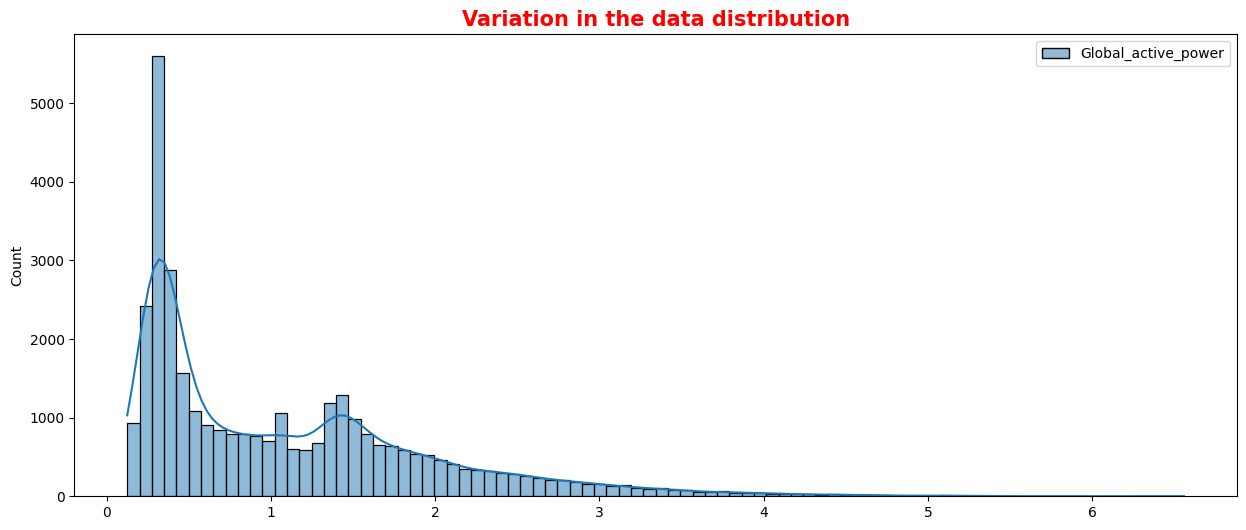

In [18]:
plt.figure(figsize = (15,6))
sns.histplot(df_el, kde=True)
plt.title("Variation in the data distribution", fontsize = 15, color = 'r', weight = 'bold')
plt.show()

## Sunspot

In [7]:
df_ss = pd.read_csv('/kaggle/input/sunspots/Sunspots.csv', parse_dates=['Date'], index_col='Date', infer_datetime_format=True, 
                 low_memory=False, na_values=['nan','?'])

df_ss = df_ss.apply(pd.to_numeric, errors='coerce').fillna(method='ffill')

df_ss = df_ss[['Monthly Mean Total Sunspot Number']].dropna()

<ipython-input-7-dfc96b73618b>:1: FutureWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  df_ss = pd.read_csv('/kaggle/input/sunspots/Sunspots.csv', parse_dates=['Date'], index_col='Date', infer_datetime_format=True,
<ipython-input-7-dfc96b73618b>:4: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df_ss = df_ss.apply(pd.to_numeric, errors='coerce').fillna(method='ffill')


In [5]:
df_ss.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 3265 entries, 1749-01-31 to 2021-01-31
Data columns (total 1 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Monthly Mean Total Sunspot Number  3265 non-null   float64
dtypes: float64(1)
memory usage: 51.0 KB


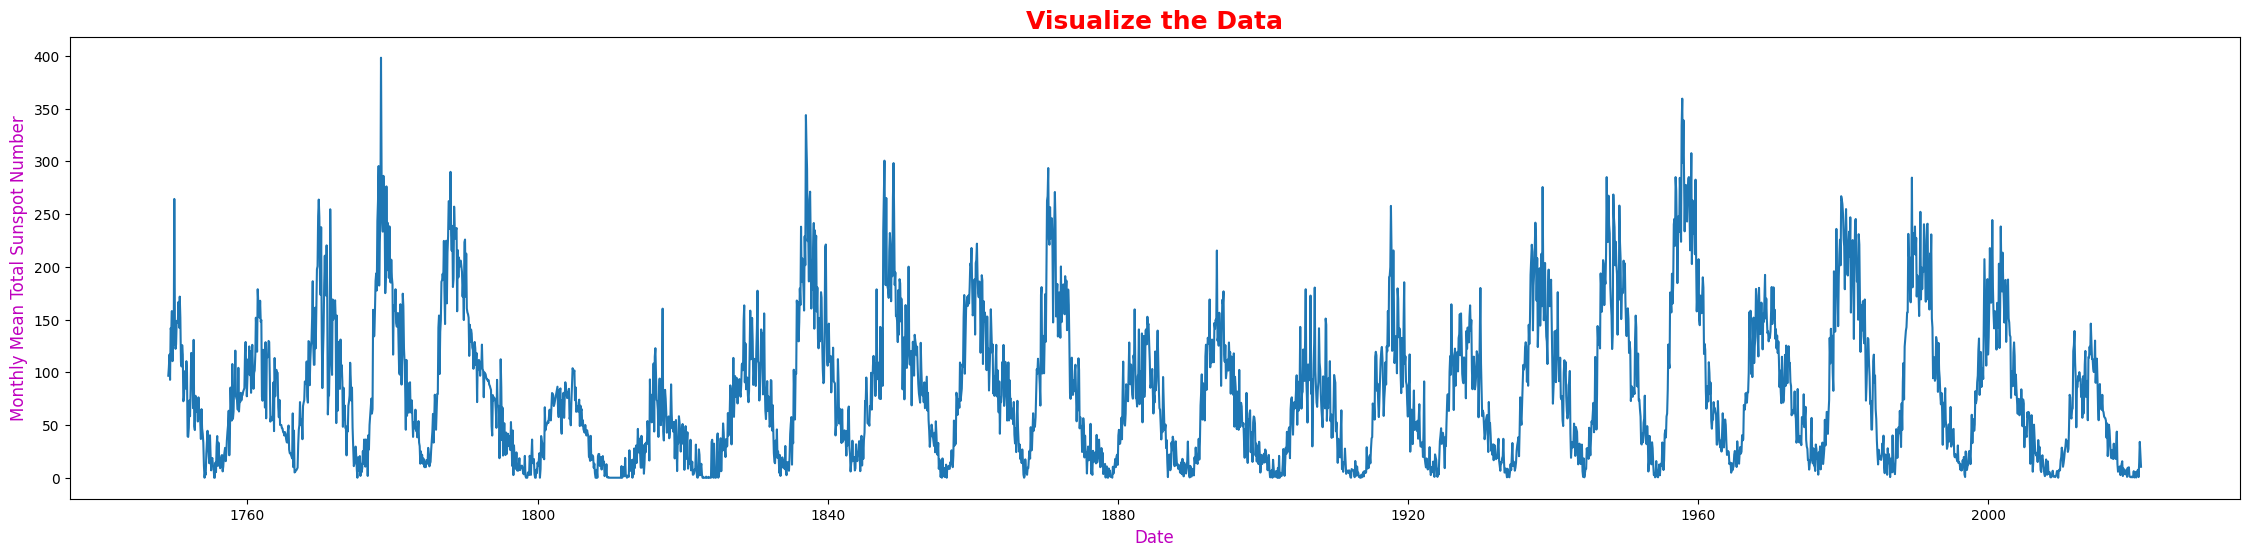

In [72]:
plt.figure(figsize=(28,6))
plt.plot(df_ss)
plt.ylabel(df_ss.columns[-1], fontsize = 12, color = 'm')
plt.xlabel("Date", fontsize = 12, color = 'm')
plt.title("Visualize the Data", fontsize = 18, color = 'r', weight = 'bold')
plt.show()

/usr/local/lib/python3.10/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.10/dist-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/usr/local/lib/python3.10/dist-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/usr/local/lib/python3.10/dist-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-l

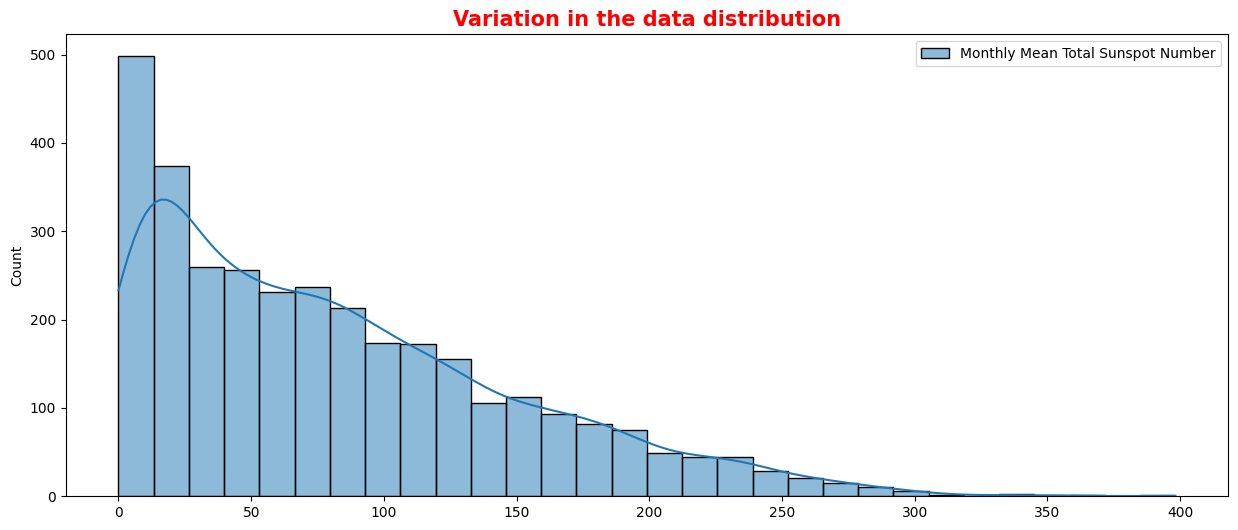

In [74]:
plt.figure(figsize = (15,6))
sns.histplot(df_ss, kde=True)
plt.title("Variation in the data distribution", fontsize = 15, color = 'r', weight = 'bold')
plt.show()

# Data Loaders

In [8]:
class TimeSeriesDataset(Dataset):
    def __init__(self, data, seq_len, pred_len):
        self.data = data 
        self.seq_len = seq_len
        self.pred_len = pred_len

    def __len__(self):
        return len(self.data) - self.seq_len - self.pred_len

    def __getitem__(self, index):
        x = self.data[index : index + self.seq_len]
        y = self.data[index + self.seq_len : index + self.seq_len + self.pred_len]
        return torch.tensor(x, dtype=torch.float32), torch.tensor(y, dtype=torch.float32)


In [9]:
def create_dataloaders(df, seq_len=96, pred_len=24, batch_size=64):
    train_size = int(len(df) * 0.7)
    val_size = int(len(df) * 0.15)
    test_size = len(df) - train_size - val_size

    train_data = df.iloc[:train_size]
    val_data = df.iloc[train_size:train_size+val_size]
    test_data = df.iloc[train_size+val_size:]

    # Scale the data
    scaler = MinMaxScaler()
    train_scaled = scaler.fit_transform(train_data)
    val_scaled = scaler.transform(val_data)
    test_scaled = scaler.transform(test_data)

    train_dataset = TimeSeriesDataset(train_scaled, seq_len, pred_len)
    val_dataset = TimeSeriesDataset(val_scaled, seq_len, pred_len)
    test_dataset = TimeSeriesDataset(test_scaled, seq_len, pred_len)

    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

    return train_loader, val_loader, test_loader


In [10]:
seq_len = 180
pred_len = 1
batch_size = 32
train_loader_el, val_loader_el, test_loader_el = create_dataloaders(df_el, seq_len, pred_len, batch_size)
train_loader_ss, val_loader_ss, test_loader_ss = create_dataloaders(df_ss, seq_len, pred_len, batch_size)

In [107]:
for xb, yb in train_loader_el:
    print(xb.shape, yb.shape)
    break


torch.Size([32, 180, 1]) torch.Size([32, 1, 1])


In [11]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Train, validation, and test preparation

In [21]:
def train_model(model, train_loader, val_loader, lr, epochs=50, return_best=True):
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    train_losses = []
    val_losses = []

    best_val_loss = float('inf')
    best_model_state = None

    for epoch in range(epochs):
        model.train()
        train_loss = 0.0
        for x_batch, y_batch in train_loader:
            x_batch, y_batch = x_batch.to(device), y_batch.to(device)
            optimizer.zero_grad()
            output = model(x_batch)
            loss = criterion(output, y_batch.squeeze(-1))
            loss.backward()
            optimizer.step()
            train_loss += loss.item()
        train_loss /= len(train_loader)
        train_losses.append(train_loss)
    
        val_loss = 0.0
        model.eval()
        with torch.no_grad():
            for x_batch, y_batch in val_loader:
                x_batch, y_batch = x_batch.to(device), y_batch.to(device)
                output = model(x_batch)
                loss = criterion(output, y_batch.squeeze(-1))
                val_loss += loss.item()
            val_loss /= len(val_loader)
            val_losses.append(val_loss)

        # Save best model
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_model_state = model.state_dict()

        # print(f"Epoch {epoch+1}/{epochs} — Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}")
    
    if return_best and best_model_state:
        model.load_state_dict(best_model_state)

    return model, train_losses, val_losses, best_val_loss


In [22]:
def test_model(model, test_loader):
    model.eval()
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    preds = []
    targets = []
    
    with torch.no_grad():
        for x_batch, y_batch in test_loader:
            x_batch, y_batch = x_batch.to(device), y_batch.to(device)
            output = model(x_batch)
            preds.extend(output.cpu().numpy().flatten())
            targets.extend(y_batch.cpu().numpy().flatten())
    
    mae = mean_absolute_error(targets, preds)
    mse = mean_squared_error(targets, preds)
    r2 = r2_score(targets, preds)

    print(f"MAE: {mae:.4f}")
    print(f"MSE: {mse:.4f}")
    print(f"R²: {r2:.4f}")

    return mae, mse, r2

# Models

## Transformer

In [94]:
import math
import torch.nn as nn

class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=500):
        super(PositionalEncoding, self).__init__()
        pe = torch.zeros(max_len, d_model).float()
        position = torch.arange(0, max_len).float().unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))

        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        pe = pe.unsqueeze(0)  # (1, max_len, d_model)
        self.register_buffer('pe', pe)

    def forward(self, x):
        # x: (batch_size, seq_len, d_model)
        return x + self.pe[:, :x.size(1)]


In [95]:
class TransformerTimeSeries(nn.Module):
    def __init__(self, input_size, d_model, nhead, num_layers, output_size, dim_feedforward=128):
        super(TransformerTimeSeries, self).__init__()
        self.input_proj = nn.Linear(input_size, d_model)
        self.pos_encoder = PositionalEncoding(d_model)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=dim_feedforward,
            batch_first=True
        )
        self.transformer_encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.decoder = nn.Linear(d_model, output_size)

    def forward(self, x):
        x = self.input_proj(x)              # (batch, seq_len, d_model)
        x = self.pos_encoder(x)             # Add positional encoding
        x = self.transformer_encoder(x)     # (batch, seq_len, d_model)
        out = self.decoder(x[:, -1, :])     # Use last time step
        return out

In [96]:
def transformer_objective(trial, train_loader, val_loader, input_size=1, output_size=1):
    d_model = trial.suggest_categorical("d_model", [16, 32, 64, 128])
    nhead = trial.suggest_categorical("nhead", [1, 2, 4, 8])
    
    if d_model % nhead != 0:
        raise optuna.exceptions.TrialPruned()
    
    num_layers = trial.suggest_int("num_layers", 1, 50)
    lr = trial.suggest_float("lr", 1e-4, 1e-2, log=True)
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
 

    model = TransformerTimeSeries(
        input_size=input_size,
        d_model=d_model,
        nhead=nhead,
        num_layers=num_layers,
        output_size=output_size
    ).to(device)

    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    model.train()
    for epoch in range(10):  # fast tuning
        for x_batch, y_batch in train_loader:
            x_batch, y_batch = x_batch.to(device), y_batch.to(device)
            optimizer.zero_grad()
            output = model(x_batch)
            loss = criterion(output, y_batch.squeeze(-1))
            loss.backward()
            optimizer.step()

    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for x_batch, y_batch in val_loader:
            x_batch, y_batch = x_batch.to(device), y_batch.to(device)
            output = model(x_batch)
            loss = criterion(output, y_batch.squeeze(-1))
            val_loss += loss.item()

    return val_loss / len(val_loader)


### Optimized for sun spot

In [39]:
transformer_ss = optuna.create_study(direction="minimize")
transformer_ss.optimize(lambda trial: transformer_objective(trial, train_loader_ss, val_loader_ss), n_trials=20)

print("Best Transformer params — Sun Spots:")
print(transformer_ss.best_params)


[I 2025-04-21 10:59:01,783] A new study created in memory with name: no-name-6ebc8b42-5725-4dec-b931-ff1a97cd8e59
[I 2025-04-21 10:59:58,678] Trial 0 finished with value: 0.023376088496297596 and parameters: {'d_model': 32, 'nhead': 8, 'num_layers': 23, 'lr': 0.00016846139966403918}. Best is trial 0 with value: 0.023376088496297596.
[I 2025-04-21 11:00:21,349] Trial 1 finished with value: 0.005379399040248245 and parameters: {'d_model': 64, 'nhead': 8, 'num_layers': 8, 'lr': 0.0007508771852638132}. Best is trial 1 with value: 0.005379399040248245.
[I 2025-04-21 11:03:21,713] Trial 2 finished with value: 0.044608925096690656 and parameters: {'d_model': 128, 'nhead': 8, 'num_layers': 46, 'lr': 0.0005800558900838624}. Best is trial 1 with value: 0.005379399040248245.
[I 2025-04-21 11:05:18,939] Trial 3 finished with value: 0.04992649098858237 and parameters: {'d_model': 128, 'nhead': 1, 'num_layers': 43, 'lr': 0.0007064004933391825}. Best is trial 1 with value: 0.005379399040248245.
[I 20

Best Transformer params — Electricity:
{'d_model': 64, 'nhead': 2, 'num_layers': 1, 'lr': 0.0031384608014711174}


In [28]:
model_transformer_ss = TransformerTimeSeries(
    input_size=1,
    d_model=64,
    nhead=2,
    num_layers=1,
    output_size=1
).to(device)


In [29]:
%%time
best_model_transformer_ss, train_losses_transformer_ss, val_losses_transformer_ss, best_val_loss_transformer_ss = train_model(model_transformer_ss, train_loader_ss, val_loader_ss, lr=0.00313846)

CPU times: user 14.8 s, sys: 158 ms, total: 15 s
Wall time: 15.1 s


In [30]:
pd_transformer_ss = pd.DataFrame({'train_loss': train_losses_transformer_ss, 'val_loss': val_losses_transformer_ss})
pd_transformer_ss

,train_loss,val_loss
0,0.049095,0.005320
1,0.006038,0.004886
2,0.005368,0.004579
3,0.005270,0.004618
4,0.004798,0.004911
5,0.004533,0.005241
6,0.005510,0.006020
7,0.004651,0.007406
8,0.005038,0.005668
9,0.004592,0.004622


In [31]:
mae_transformer_ss, mse_transformer_ss, r2_transformer_ss = test_model(best_model_transformer_ss, test_loader_ss)

MAE: 0.0325
MSE: 0.0022
R²: 0.8943


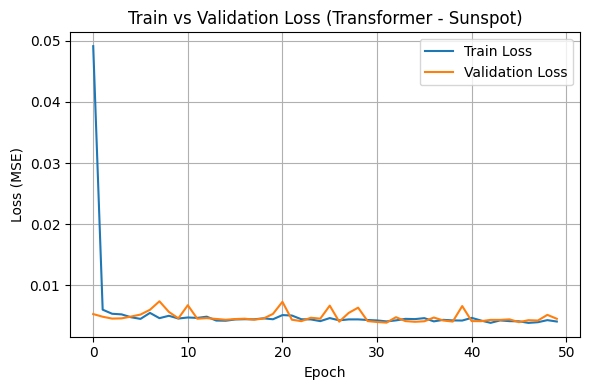

In [32]:
plt.figure(figsize=(6, 4))
plt.plot(train_losses_transformer_ss, label='Train Loss')
plt.plot(val_losses_transformer_ss, label='Validation Loss')
plt.title('Train vs Validation Loss (Transformer - Sunspot)')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [38]:
model_transformer_ss_el = TransformerTimeSeries(
    input_size=1,
    d_model=64,
    nhead=2,
    num_layers=1,
    output_size=1
).to(device)


In [39]:
%%time
best_model_transformer_ss_el, train_losses_transformer_ss_el, val_losses_transformer_ss_el, best_val_loss_transformer_ss_el = train_model(model_transformer_ss_el, train_loader_el, val_loader_el, lr=0.00313846)

CPU times: user 2min 49s, sys: 1.49 s, total: 2min 50s
Wall time: 2min 51s


In [40]:
mae_transformer_ss_el, mse_transformer_ss_el, r2_transformer_ss_el = test_model(best_model_transformer_ss_el, test_loader_el)

MAE: 0.0547
MSE: 0.0059
R²: 0.5084


In [41]:
pd_transformer_ss_el = pd.DataFrame({'train_loss': train_losses_transformer_ss_el, 'val_loss': val_losses_transformer_ss_el})
pd_transformer_ss_el

,train_loss,val_loss
0,0.013917,0.008205
1,0.009856,0.008741
2,0.009348,0.008326
3,0.009456,0.008299
4,0.009183,0.008282
5,0.009162,0.008194
6,0.008986,0.009122
7,0.009036,0.008215
8,0.008933,0.008542
9,0.008864,0.008505


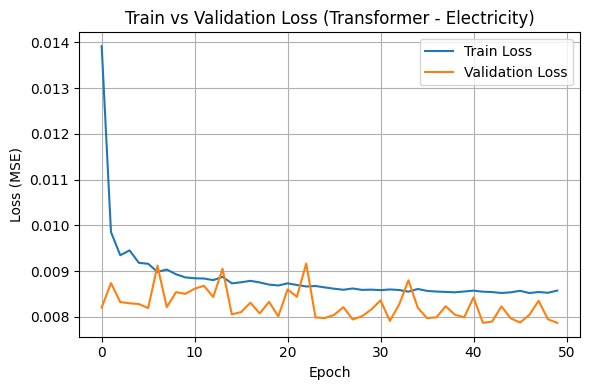

In [43]:
plt.figure(figsize=(6, 4))
plt.plot(train_losses_transformer_ss_el, label='Train Loss')
plt.plot(val_losses_transformer_ss_el, label='Validation Loss')
plt.title('Train vs Validation Loss (Transformer - Electricity)')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

### Optimized for electricity

In [97]:
transformer_el = optuna.create_study(direction="minimize")
transformer_el.optimize(lambda trial: transformer_objective(trial, train_loader_el, val_loader_el), n_trials=20)

print("Best Transformer params — Electricity:")
print(transformer_el.best_params)

[I 2025-04-23 13:56:53,809] A new study created in memory with name: no-name-8dd8e9a5-a440-4bf1-879d-73272dfd1e17
[I 2025-04-23 14:10:16,367] Trial 0 finished with value: 0.019280368616436696 and parameters: {'d_model': 64, 'nhead': 2, 'num_layers': 41, 'lr': 0.005259164242118496}. Best is trial 0 with value: 0.019280368616436696.
[I 2025-04-23 14:19:19,588] Trial 1 finished with value: 0.007849235910696873 and parameters: {'d_model': 32, 'nhead': 8, 'num_layers': 19, 'lr': 0.0002499066869911526}. Best is trial 1 with value: 0.007849235910696873.
/usr/local/lib/python3.10/dist-packages/torch/nn/modules/transformer.py:379: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.num_heads is odd
  warnings.warn(
[I 2025-04-23 14:43:45,258] Trial 2 finished with value: 0.020496642489911645 and parameters: {'d_model': 128, 'nhead': 1, 'num_layers': 47, 'lr': 0.0046468634612359845}. Best is trial 1 with value: 0.007849235910696873.
[I 2

Best Transformer params — Electricity:
{'d_model': 32, 'nhead': 8, 'num_layers': 10, 'lr': 0.000292697680646546}


In [98]:
model_transformer_el = TransformerTimeSeries(
    input_size=1,
    d_model=32,
    nhead=8,
    num_layers=10,
    output_size=1
).to(device)
lr_transformer_el=0.00029270

In [99]:
%%time
best_model_transformer_el, train_losses_transformer_el, val_losses_transformer_el, best_val_loss_transformer_el = train_model(model_transformer_el, train_loader_el, val_loader_el, lr=lr_transformer_el)

CPU times: user 25min 40s, sys: 2.39 s, total: 25min 42s
Wall time: 25min 45s


In [100]:
pd_transformer_el = pd.DataFrame({'train_loss': train_losses_transformer_el, 'val_loss': val_losses_transformer_el})
pd_transformer_el

,train_loss,val_loss
0,0.021601,0.010031
1,0.011771,0.009824
2,0.010736,0.008618
3,0.009876,0.008631
4,0.009402,0.007928
5,0.009122,0.007653
6,0.009002,0.008558
7,0.008959,0.008230
8,0.008737,0.007664
9,0.008661,0.007474


In [101]:
mae_transformer_el, mse_transformer_el, r2_transformer_el = test_model(best_model_transformer_el, test_loader_el)

MAE: 0.0524
MSE: 0.0060
R²: 0.5061


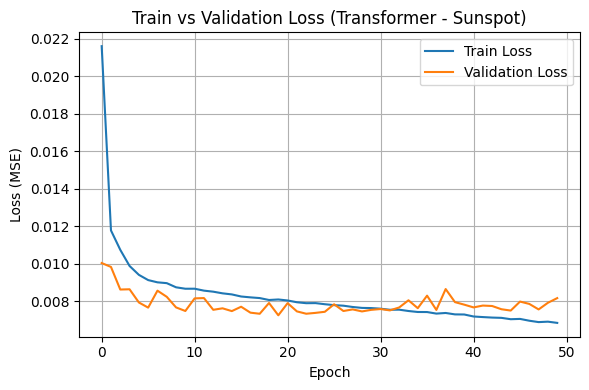

In [102]:
plt.figure(figsize=(6, 4))
plt.plot(train_losses_transformer_el, label='Train Loss')
plt.plot(val_losses_transformer_el, label='Validation Loss')
plt.title('Train vs Validation Loss (Transformer - Sunspot)')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [106]:
model_transformer_el_ss = TransformerTimeSeries(
    input_size=1,
    d_model=32,
    nhead=8,
    num_layers=10,
    output_size=1
)
model_transformer_el_ss = nn.DataParallel(model_transformer_el_ss)
model_transformer_el_ss.to(device)

DataParallel(
  (module): TransformerTimeSeries(
    (input_proj): Linear(in_features=1, out_features=32, bias=True)
    (pos_encoder): PositionalEncoding()
    (transformer_encoder): TransformerEncoder(
      (layers): ModuleList(
        (0-9): 10 x TransformerEncoderLayer(
          (self_attn): MultiheadAttention(
            (out_proj): NonDynamicallyQuantizableLinear(in_features=32, out_features=32, bias=True)
          )
          (linear1): Linear(in_features=32, out_features=128, bias=True)
          (dropout): Dropout(p=0.1, inplace=False)
          (linear2): Linear(in_features=128, out_features=32, bias=True)
          (norm1): LayerNorm((32,), eps=1e-05, elementwise_affine=True)
          (norm2): LayerNorm((32,), eps=1e-05, elementwise_affine=True)
          (dropout1): Dropout(p=0.1, inplace=False)
          (dropout2): Dropout(p=0.1, inplace=False)
        )
      )
    )
    (decoder): Linear(in_features=32, out_features=1, bias=True)
  )
)

In [107]:
%%time
best_model_transformer_el_ss, train_losses_transformer_el_ss, val_losses_transformer_el_ss, best_val_loss_transformer_el_ss = train_model(model_transformer_el_ss, train_loader_ss, val_loader_ss, lr=lr_transformer_el)

CPU times: user 3min 29s, sys: 12.7 s, total: 3min 42s
Wall time: 2min 27s


In [108]:
pd_transformer_el_ss = pd.DataFrame({'train_loss': train_losses_transformer_el_ss, 'val_loss': val_losses_transformer_el_ss})
pd_transformer_el_ss

,train_loss,val_loss
0,0.045942,0.040581
1,0.027478,0.025053
2,0.013431,0.007529
3,0.008999,0.006846
4,0.008562,0.006004
5,0.007904,0.005714
6,0.007330,0.006025
7,0.006767,0.006291
8,0.006452,0.004636
9,0.006582,0.004960


In [109]:
mae_transformer_el_ss, mse_transformer_el_ss, r2_transformer_el_ss = test_model(best_model_transformer_el_ss, test_loader_ss)

MAE: 0.0335
MSE: 0.0024
R²: 0.8809


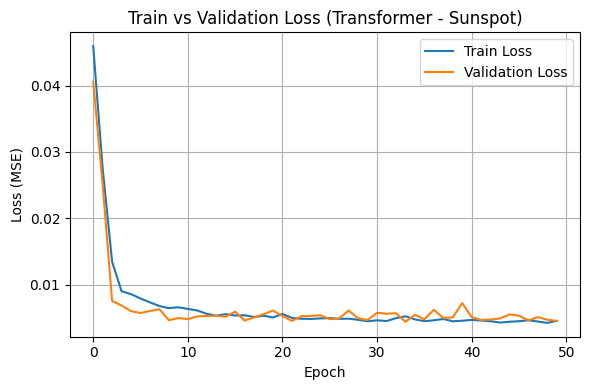

In [110]:
plt.figure(figsize=(6, 4))
plt.plot(train_losses_transformer_el_ss, label='Train Loss')
plt.plot(val_losses_transformer_el_ss, label='Validation Loss')
plt.title('Train vs Validation Loss (Transformer - Sunspot)')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## Informer

In [32]:
class ProbAttention(nn.Module):
    def __init__(self, mask_flag=True, factor=5, scale=None):
        super(ProbAttention, self).__init__()
        self.mask_flag = mask_flag
        self.factor = factor
        self.scale = scale

    def forward(self, queries, keys, values):
        B, H, L_Q, D = queries.shape
        _, _, L_K, _ = keys.shape

        # scaled dot-product
        scale = self.scale or 1. / math.sqrt(D)
        scores = torch.matmul(queries, keys.transpose(-2, -1)) * scale  # (B, H, L_Q, L_K)

        # Probabilistic attention (sparsified with top-k)
        K_top = min(self.factor * int(math.log(L_K)), L_K)
        index = scores.topk(K_top, dim=-1)[1]
        context = torch.gather(values, dim=2, index=index.unsqueeze(-1).expand(-1, -1, -1, values.size(-1)))

        scores = torch.gather(scores, dim=-1, index=index)
        attn = torch.softmax(scores, dim=-1)

        output = torch.sum(attn.unsqueeze(-1) * context, dim=2)  # (B, H, L_Q, D)
        return output


In [33]:
class ProbMultiHeadAttention(nn.Module):
    def __init__(self, d_model, n_heads, dropout=0.1):
        super(ProbMultiHeadAttention, self).__init__()
        self.d_model = d_model
        self.n_heads = n_heads
        self.head_dim = d_model // n_heads

        self.query = nn.Linear(d_model, d_model)
        self.key = nn.Linear(d_model, d_model)
        self.value = nn.Linear(d_model, d_model)
        self.out_proj = nn.Linear(d_model, d_model)

        self.attn = ProbAttention()
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        B, L, D = x.shape
        q = self.query(x).view(B, L, self.n_heads, self.head_dim).transpose(1, 2)  # (B, H, L, D)
        k = self.key(x).view(B, L, self.n_heads, self.head_dim).transpose(1, 2)
        v = self.value(x).view(B, L, self.n_heads, self.head_dim).transpose(1, 2)

        out = self.attn(q, k, v)  # (B, H, L, D)
        out = out.transpose(1, 2).contiguous().view(B, L, D)
        return self.dropout(self.out_proj(out))


In [34]:
class FixedPositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=500):
        super(FixedPositionalEncoding, self).__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len).unsqueeze(1).float()
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))

        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)

        self.pe = pe.unsqueeze(0)  # (1, max_len, d_model)

    def forward(self, x):
        return x + self.pe[:, :x.size(1)].to(x.device)


In [35]:
class EncoderLayer(nn.Module):
    def __init__(self, d_model, n_heads, dropout=0.1):
        super(EncoderLayer, self).__init__()
        self.attn = ProbMultiHeadAttention(d_model, n_heads, dropout)
        self.ffn = nn.Sequential(
            nn.Linear(d_model, d_model * 4),
            nn.ReLU(),
            nn.Linear(d_model * 4, d_model)
        )
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        x2 = self.attn(x)
        x = self.norm1(x + self.dropout(x2))
        x2 = self.ffn(x)
        x = self.norm2(x + self.dropout(x2))
        return x


In [36]:
class InformerTimeSeries(nn.Module):
    def __init__(self, input_size, d_model, n_heads, num_layers, output_size, dropout=0.1):
        super(InformerTimeSeries, self).__init__()
        self.input_proj = nn.Linear(input_size, d_model)
        self.pos_encoder = FixedPositionalEncoding(d_model)
        self.encoder_layers = nn.ModuleList([
            EncoderLayer(d_model, n_heads, dropout) for _ in range(num_layers)
        ])
        self.proj_out = nn.Linear(d_model, output_size)

    def forward(self, x):
        x = self.input_proj(x)                   # (B, seq_len, d_model)
        x = self.pos_encoder(x)                  # (B, seq_len, d_model)
        for layer in self.encoder_layers:
            x = layer(x)                         # (B, seq_len, d_model)
        return self.proj_out(x[:, -1, :])        # Use last time step


In [37]:
class ProbAttention(nn.Module):
    def __init__(self, mask_flag=True, factor=5, scale=None):
        super(ProbAttention, self).__init__()
        self.mask_flag = mask_flag
        self.factor = factor
        self.scale = scale

    def forward(self, queries, keys, values):
        B, H, L_Q, D = queries.shape
        _, _, L_K, _ = keys.shape

        scale = self.scale or 1. / math.sqrt(D)
        scores = torch.matmul(queries, keys.transpose(-2, -1)) * scale  # (B, H, L_Q, L_K)

        # Top-k sparse attention
        K_top = min(self.factor * int(math.log(L_K)), L_K)
        topk_scores, index = scores.topk(K_top, dim=-1)  # (B, H, L_Q, K_top)

        # Expand to match values for gather
        index_exp = index.unsqueeze(-1).expand(-1, -1, -1, K_top, values.size(-1))
        V_exp = values.unsqueeze(2).expand(-1, -1, L_Q, -1, -1)  # (B, H, L_Q, L_K, D)
        gathered_values = torch.gather(V_exp, 3, index_exp)     # (B, H, L_Q, K_top, D)

        attn = torch.softmax(topk_scores, dim=-1).unsqueeze(-1)  # (B, H, L_Q, K_top, 1)
        output = torch.sum(attn * gathered_values, dim=3)        # (B, H, L_Q, D)
        return output


In [38]:
def informer_objective(trial, train_loader, val_loader, input_size=1, output_size=1):
    d_model = trial.suggest_categorical("d_model", [16, 32, 64, 128])
    n_heads = trial.suggest_categorical("n_heads", [2, 4, 8, 16])
    num_layers = trial.suggest_int("num_layers", 1, 50)
    lr = trial.suggest_float("lr", 1e-4, 1e-2, log=True)

    model = nn.DataParallel(InformerTimeSeries(
        input_size=input_size,
        d_model=d_model,
        n_heads=n_heads,
        num_layers=num_layers,
        output_size=output_size
    )).to(device)

    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    model.train()
    for epoch in range(10):
        for x_batch, y_batch in train_loader:
            x_batch, y_batch = x_batch.to(device), y_batch.to(device)
            optimizer.zero_grad()
            output = model(x_batch)
            loss = criterion(output, y_batch.squeeze(-1))
            loss.backward()
            optimizer.step()

    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for x_batch, y_batch in val_loader:
            x_batch, y_batch = x_batch.to(device), y_batch.to(device)
            output = model(x_batch)
            loss = criterion(output, y_batch.squeeze(-1))
            val_loss += loss.item()

    return val_loss / len(val_loader)


### Optimized for sun spot

In [65]:
study_informer_ss = optuna.create_study(direction="minimize")
study_informer_ss.optimize(lambda trial: informer_objective(trial, train_loader_ss, val_loader_ss), n_trials=20)

print("Best Informer params — Sunspot:")
print(study_informer_ss.best_params)

[I 2025-04-21 11:35:58,310] A new study created in memory with name: no-name-f7196886-1e92-4fd3-a631-6c223cf4501b
[I 2025-04-21 11:41:29,765] Trial 0 finished with value: 0.06391056936699897 and parameters: {'d_model': 32, 'n_heads': 16, 'num_layers': 30, 'lr': 0.0032716326417551356}. Best is trial 0 with value: 0.06391056936699897.
[I 2025-04-21 11:44:52,181] Trial 1 finished with value: 0.05996040380559862 and parameters: {'d_model': 16, 'n_heads': 8, 'num_layers': 34, 'lr': 0.0030624684794164606}. Best is trial 1 with value: 0.05996040380559862.
[I 2025-04-21 11:47:05,318] Trial 2 finished with value: 0.006294891680590808 and parameters: {'d_model': 16, 'n_heads': 8, 'num_layers': 23, 'lr': 0.0009513907254706434}. Best is trial 2 with value: 0.006294891680590808.
[I 2025-04-21 11:55:24,527] Trial 3 finished with value: 0.04645363944582641 and parameters: {'d_model': 64, 'n_heads': 16, 'num_layers': 38, 'lr': 0.0062950690430190245}. Best is trial 2 with value: 0.006294891680590808.
[

Best Informer params — Sunspot:
{'d_model': 64, 'n_heads': 2, 'num_layers': 21, 'lr': 0.00010449587500173626}


In [22]:
model_informer_ss = InformerTimeSeries(
    input_size=1,
    d_model=64,
    n_heads=2,
    num_layers=21,
    output_size=1
).to(device)
lr_informer_ss = 0.00010450

In [53]:
%%time
best_model_informer_ss, train_losses_informer_ss, val_losses_informer_ss, best_val_loss_informer_ss = train_model(model_informer_ss, train_loader_ss, val_loader_ss, lr=lr_informer_ss)

CPU times: user 8min 34s, sys: 43.8 s, total: 9min 17s
Wall time: 9min 18s


In [54]:
mae_informer_ss, mse_informer_ss, r2_informer_ss = test_model(best_model_informer_ss, test_loader_ss)

MAE: 0.0368
MSE: 0.0028
R²: 0.8618


In [55]:
df_informer_ss = pd.DataFrame({'train_loss': train_losses_informer_ss, 'val_loss': val_losses_informer_ss})
df_informer_ss

,train_loss,val_loss
0,0.081913,0.044437
1,0.034083,0.020966
2,0.018568,0.010513
3,0.015538,0.005870
4,0.011748,0.005264
5,0.009916,0.004511
6,0.008982,0.004582
7,0.007827,0.004683
8,0.007670,0.005240
9,0.006843,0.005731


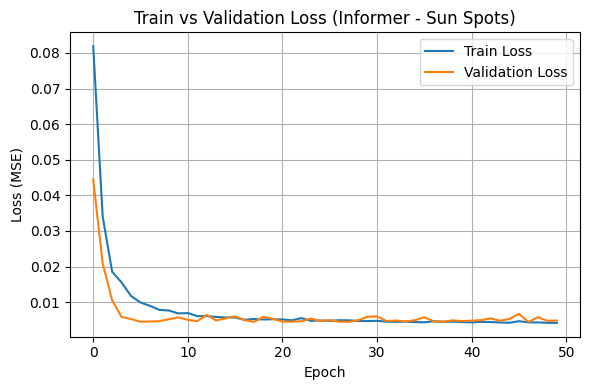

In [56]:
plt.figure(figsize=(6, 4))
plt.plot(train_losses_informer_ss, label='Train Loss')
plt.plot(val_losses_informer_ss, label='Validation Loss')
plt.title('Train vs Validation Loss (Informer - Sun Spots)')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [23]:
model_informer_ss_el= InformerTimeSeries(
    input_size=1,
    d_model=64,
    n_heads=2,
    num_layers=21,
    output_size=1
).to(device)

In [24]:
%%time
best_model_infromer_ss_el, train_losses_informer_ss_el, val_losses_informer_ss_el, best_val_loss_ss_el = train_model(model_informer_ss_el, train_loader_el, val_loader_el, lr=lr_informer_ss)

CPU times: user 1h 40min 20s, sys: 9min 28s, total: 1h 49min 48s
Wall time: 1h 49min 53s


In [26]:
mae_informer_ss_el, mse_informer_ss_el, r2_informer_ss_el = test_model(best_model_infromer_ss_el, test_loader_el)

MAE: 0.0498
MSE: 0.0057
R²: 0.5289


In [27]:
df_informer_ss_el = pd.DataFrame({'train_loss': train_losses_informer_ss_el, 'val_loss': val_losses_informer_ss_el})
df_informer_ss_el

,train_loss,val_loss
0,0.021899,0.008694
1,0.010716,0.007932
2,0.009592,0.007848
3,0.009194,0.007794
4,0.008969,0.008304
5,0.008795,0.007444
6,0.008721,0.009018
7,0.008766,0.007388
8,0.008616,0.007495
9,0.008487,0.007535


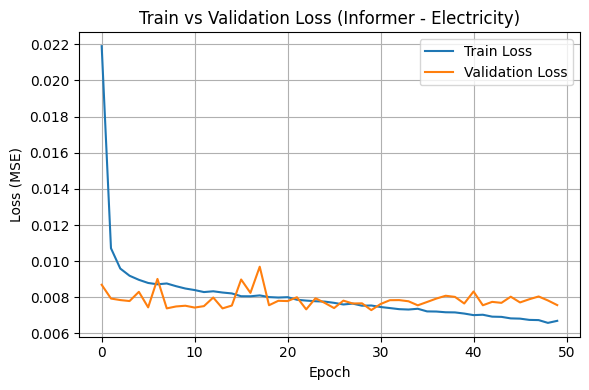

In [28]:
plt.figure(figsize=(6, 4))
plt.plot(train_losses_informer_ss_el, label='Train Loss')
plt.plot(val_losses_informer_ss_el, label='Validation Loss')
plt.title('Train vs Validation Loss (Informer - Electricity)')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

### Optimized for electricity

In [ ]:
study_informer_el = optuna.create_study(direction="minimize")
study_informer_el.optimize(lambda trial: informer_objective(trial, train_loader_el, val_loader_el), n_trials=10)

print("Best Informer params — Electricity:")
print(study_informer_el.best_params)

[I 2025-04-23 17:17:39,228] A new study created in memory with name: no-name-e443107d-17f0-4e76-89f0-103ac10a9438
[I 2025-04-23 17:50:24,355] Trial 0 finished with value: 0.020596483606655315 and parameters: {'d_model': 32, 'n_heads': 16, 'num_layers': 27, 'lr': 0.004024121670772104}. Best is trial 0 with value: 0.020596483606655315.
[I 2025-04-23 18:08:44,420] Trial 1 finished with value: 0.02004540326655101 and parameters: {'d_model': 128, 'n_heads': 16, 'num_layers': 10, 'lr': 0.006680784340606313}. Best is trial 1 with value: 0.02004540326655101.
[I 2025-04-23 18:12:55,460] Trial 2 finished with value: 0.007681862842647513 and parameters: {'d_model': 16, 'n_heads': 16, 'num_layers': 4, 'lr': 0.0003003831571949541}. Best is trial 2 with value: 0.007681862842647513.
[I 2025-04-23 18:28:57,596] Trial 3 finished with value: 0.021897270361993723 and parameters: {'d_model': 128, 'n_heads': 2, 'num_layers': 16, 'lr': 0.0018764830054878866}. Best is trial 2 with value: 0.007681862842647513

In [41]:
model_informer_el = InformerTimeSeries(
    input_size=1,
    d_model=16,
    n_heads=16,
    num_layers=4,
    output_size=1
).to(device)
lr_informer_el = 0.00030038

In [42]:
%%time
best_model_informer_el, train_losses_informer_el, val_losses_informer_el, best_val_loss_informer_el = train_model(model_informer_el, train_loader_el, val_loader_el, lr=lr_informer_el)

CPU times: user 39min 52s, sys: 2.76 s, total: 39min 55s
Wall time: 39min 56s


In [43]:
mae_informer_el, mse_informer_el, r2_informer_el = test_model(best_model_informer_el, test_loader_el)

MAE: 0.0503
MSE: 0.0057
R²: 0.5284


In [44]:
df_informer_el = pd.DataFrame({'train_loss': train_losses_informer_el, 'val_loss': val_losses_informer_el})
df_informer_el

,train_loss,val_loss
0,0.022814,0.010058
1,0.010657,0.009051
2,0.009757,0.008497
3,0.009188,0.008828
4,0.009008,0.008026
5,0.008738,0.008387
6,0.008843,0.007999
7,0.008528,0.007932
8,0.008584,0.008714
9,0.008480,0.008384


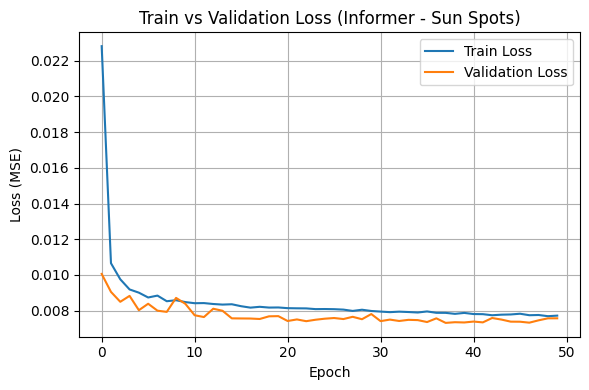

In [45]:
plt.figure(figsize=(6, 4))
plt.plot(train_losses_informer_el, label='Train Loss')
plt.plot(val_losses_informer_el, label='Validation Loss')
plt.title('Train vs Validation Loss (Informer - Sun Spots)')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [46]:
model_informer_el_ss = InformerTimeSeries(
    input_size=1,
    d_model=16,
    n_heads=16,
    num_layers=4,
    output_size=1
).to(device)

In [47]:
%%time
best_model_informer_el_ss, train_losses_informer_el_ss, val_losses_informer_el_ss, best_val_loss_informer_el_ss = train_model(model_informer_el_ss, train_loader_ss, val_loader_ss, lr=lr_informer_el)

CPU times: user 3min 17s, sys: 235 ms, total: 3min 17s
Wall time: 3min 17s


In [48]:
mae_informer_el_ss, mse_informer_el_ss, r2_informer_el_ss = test_model(best_model_informer_el_ss, test_loader_ss)

MAE: 0.0456
MSE: 0.0032
R²: 0.8422


In [49]:
df_informer_el_ss = pd.DataFrame({'train_loss': train_losses_informer_el_ss, 'val_loss': val_losses_informer_el_ss})
df_informer_el_ss

,train_loss,val_loss
0,0.084249,0.037594
1,0.032732,0.025454
2,0.020320,0.009677
3,0.013906,0.008439
4,0.011402,0.006978
5,0.010124,0.006330
6,0.009056,0.005712
7,0.008763,0.005407
8,0.008251,0.004900
9,0.007595,0.005411


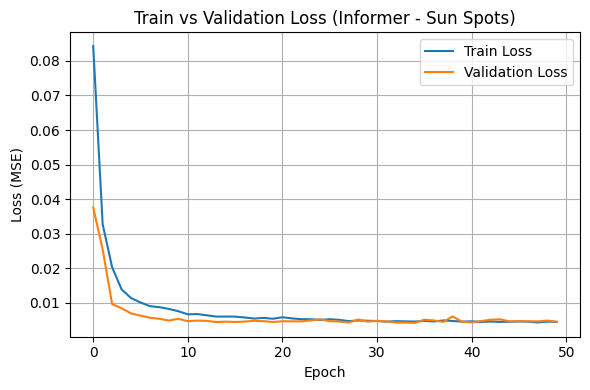

In [50]:
plt.figure(figsize=(6, 4))
plt.plot(train_losses_informer_el_ss, label='Train Loss')
plt.plot(val_losses_informer_el_ss, label='Validation Loss')
plt.title('Train vs Validation Loss (Informer - Sun Spots)')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## GLinear

In [31]:
class GLinear(nn.Module):
    def __init__(self, seq_len=180, pred_len=1, in_num_features=1):
        super(GLinear, self).__init__()
        self.seq_len = seq_len
        self.pred_len = pred_len
        self.in_num_features = in_num_features
        self.Linear = nn.Linear(self.seq_len, self.seq_len)
        self.GeLU = nn.GELU()
        self.Hidden1 = nn.Linear(self.seq_len, self.pred_len)
    
    def forward(self, x):
        x3 = x.permute(0,2,1)
        x3 = self.Linear(x3)
        x3 = self.GeLU(x3)
        x3 = self.Hidden1(x3)
        x3 = x3.permute(0,2,1)
        return x3.squeeze(-1)

In [30]:
def glinear_objective(trial, train_loader, val_loader):
    lr = trial.suggest_float("lr", 1e-4, 1e-2, log=True)

    model = GLinear().to(device)
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    model.train()
    for epoch in range(10):
        for x_batch, y_batch in train_loader:
            x_batch, y_batch = x_batch.to(device), y_batch.to(device)
            optimizer.zero_grad()
            output = model(x_batch)
            loss = criterion(output, y_batch.squeeze(-1))
            loss.backward()
            optimizer.step()

    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for x_batch, y_batch in val_loader:
            x_batch, y_batch = x_batch.to(device), y_batch.to(device)
            output = model(x_batch)
            loss = criterion(output, y_batch.squeeze(-1))
            val_loss += loss.item()

    return val_loss / len(val_loader)


### Optimised for sunspot

In [87]:
study_glinear_ss = optuna.create_study(direction="minimize")
study_glinear_ss.optimize(lambda trial: glinear_objective(trial, train_loader_ss, val_loader_ss), n_trials=20)

print("Best GLinear params — Sunspot:")
print(study_glinear_ss.best_params)


[I 2025-04-21 14:46:50,250] A new study created in memory with name: no-name-130f5999-b5f7-44bc-a905-c76466357be9
[I 2025-04-21 14:46:51,489] Trial 0 finished with value: 0.005809281405527144 and parameters: {'lr': 0.0007065130471299462}. Best is trial 0 with value: 0.005809281405527144.
[I 2025-04-21 14:46:52,790] Trial 1 finished with value: 0.005615354282781482 and parameters: {'lr': 0.001524052320192376}. Best is trial 1 with value: 0.005615354282781482.
[I 2025-04-21 14:46:54,033] Trial 2 finished with value: 0.005185146420262754 and parameters: {'lr': 0.0012584217399811293}. Best is trial 2 with value: 0.005185146420262754.
[I 2025-04-21 14:46:55,241] Trial 3 finished with value: 0.0047027556458488105 and parameters: {'lr': 0.0004878494490406021}. Best is trial 3 with value: 0.0047027556458488105.
[I 2025-04-21 14:46:56,511] Trial 4 finished with value: 0.004991052648983895 and parameters: {'lr': 0.0002953386100174933}. Best is trial 3 with value: 0.0047027556458488105.
[I 2025-0

Best GLinear params — Sunspot:
{'lr': 0.0006180749188950835}


In [32]:
model_glinear_ss = GLinear().to(device)
lr_glinear_ss = 0.00061807

In [33]:
%%time
best_model_glinear_ss, train_losses_glinear_ss, val_losses_glinear_ss, best_val_loss_glinear_ss = train_model(model_glinear_ss, train_loader_ss, val_loader_ss, lr=lr_glinear_ss)

CPU times: user 6.72 s, sys: 164 ms, total: 6.88 s
Wall time: 7.06 s


In [34]:
mae_glinear_ss, mse_glinear_ss, r2_glinear_ss = test_model(best_model_glinear_ss, test_loader_ss)

MAE: 0.0362
MSE: 0.0025
R²: 0.8780


In [36]:
df_glinear_ss = pd.DataFrame({'train_loss': train_losses_glinear_ss, 'val_loss': val_losses_glinear_ss})
df_glinear_ss

,train_loss,val_loss
0,0.014441,0.008517
1,0.005731,0.005149
2,0.004929,0.004827
3,0.004517,0.004991
4,0.004517,0.004429
5,0.004239,0.004556
6,0.004083,0.004238
7,0.004013,0.005133
8,0.003946,0.004432
9,0.003820,0.004379


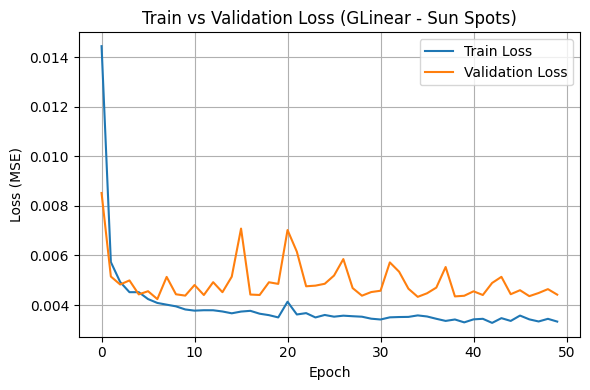

In [38]:
plt.figure(figsize=(6, 4))
plt.plot(train_losses_glinear_ss, label='Train Loss')
plt.plot(val_losses_glinear_ss, label='Validation Loss')
plt.title('Train vs Validation Loss (GLinear - Sun Spots)')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [39]:
model_glinear_ss_el = GLinear().to(device)

In [40]:
%%time
best_model_glinear_ss_el, train_losses_glinear_ss_el, val_losses_glinear_ss_el, best_val_loss_glinear_ss_el = train_model(model_glinear_ss_el, train_loader_el, val_loader_el, lr=lr_glinear_ss)

CPU times: user 1min 19s, sys: 1.78 s, total: 1min 21s
Wall time: 1min 22s


In [41]:
mae_glinear_ss_el, mse_glinear_ss_el, r2_glinear_ss_el = test_model(best_model_glinear_ss_el, test_loader_el)

MAE: 0.0541
MSE: 0.0060
R²: 0.5046


In [42]:
df_glinear_ss_el = pd.DataFrame({'train_loss': train_losses_glinear_ss_el, 'val_loss': val_losses_glinear_ss_el})
df_glinear_ss_el

,train_loss,val_loss
0,0.010124,0.007896
1,0.008434,0.007689
2,0.008445,0.007726
3,0.008239,0.008348
4,0.008121,0.007586
5,0.008093,0.007771
6,0.007992,0.008171
7,0.007945,0.007467
8,0.007897,0.007554
9,0.007843,0.007771


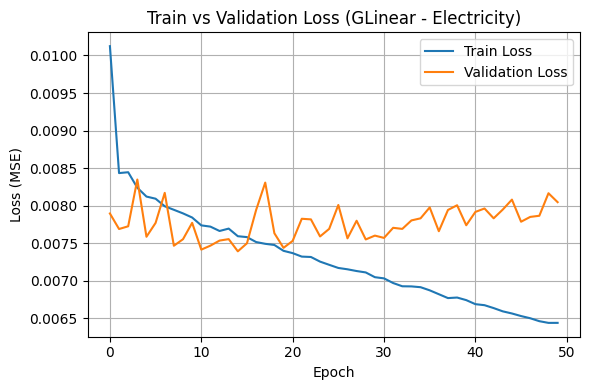

In [43]:
plt.figure(figsize=(6, 4))
plt.plot(train_losses_glinear_ss_el, label='Train Loss')
plt.plot(val_losses_glinear_ss_el, label='Validation Loss')
plt.title('Train vs Validation Loss (GLinear - Electricity)')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

### Optimised for Electricity

In [81]:
study_glinear_el = optuna.create_study(direction="minimize")
study_glinear_el.optimize(lambda trial: glinear_objective(trial, train_loader_el, val_loader_el), n_trials=20)

print("Best GLinear params — Electricity:")
print(study_glinear_el.best_params)

[I 2025-04-23 13:36:33,556] A new study created in memory with name: no-name-1304309d-49a6-4cb9-9e47-7d9e5f679b36
[I 2025-04-23 13:36:48,329] Trial 0 finished with value: 0.007593654833176428 and parameters: {'lr': 0.005298241450042246}. Best is trial 0 with value: 0.007593654833176428.
[I 2025-04-23 13:37:03,211] Trial 1 finished with value: 0.007808645801606832 and parameters: {'lr': 0.0007855298213126473}. Best is trial 0 with value: 0.007593654833176428.
[I 2025-04-23 13:37:18,003] Trial 2 finished with value: 0.00746758618528486 and parameters: {'lr': 0.0011570401043832796}. Best is trial 2 with value: 0.00746758618528486.
[I 2025-04-23 13:37:32,897] Trial 3 finished with value: 0.007963457337586553 and parameters: {'lr': 0.0006434529117031503}. Best is trial 2 with value: 0.00746758618528486.
[I 2025-04-23 13:37:47,567] Trial 4 finished with value: 0.007596217810656804 and parameters: {'lr': 0.0011511940892208615}. Best is trial 2 with value: 0.00746758618528486.
[I 2025-04-23 13

Best GLinear params — Electricity:
{'lr': 0.0002913801627786744}


In [82]:
model_glinear_el = GLinear().to(device)
lr_glinear_el = 0.00029138

In [83]:
%%time
best_model_glinear_el, train_losses_glinear_el, val_losses_glinear_el, best_val_loss_glinear_el = train_model(model_glinear_el, train_loader_el, val_loader_el, lr=lr_glinear_el)

CPU times: user 1min 18s, sys: 1.69 s, total: 1min 20s
Wall time: 1min 21s


In [84]:
mae_glinear_el, mse_glinear_el, r2_glinear_el = test_model(best_model_glinear_el, test_loader_el)

MAE: 0.0523
MSE: 0.0056
R²: 0.5349


In [85]:
df_glinear_el = pd.DataFrame({'train_loss': train_losses_glinear_el, 'val_loss': val_losses_glinear_el})
df_glinear_el

,train_loss,val_loss
0,0.010323,0.007853
1,0.008420,0.007778
2,0.008269,0.007786
3,0.008216,0.007779
4,0.008160,0.007800
5,0.008120,0.007735
6,0.008085,0.008433
7,0.008051,0.008020
8,0.007967,0.007885
9,0.007950,0.007519


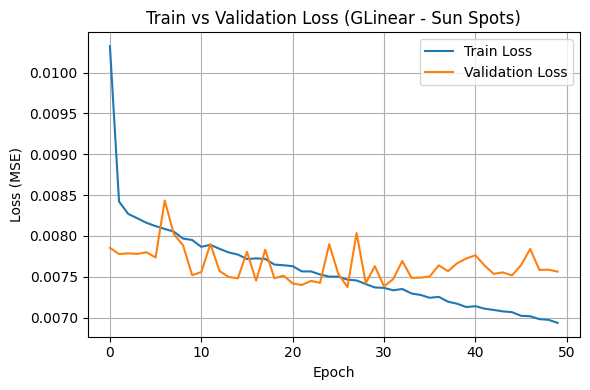

In [86]:
plt.figure(figsize=(6, 4))
plt.plot(train_losses_glinear_el, label='Train Loss')
plt.plot(val_losses_glinear_el, label='Validation Loss')
plt.title('Train vs Validation Loss (GLinear - Sun Spots)')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [87]:
model_glinear_el_ss = GLinear().to(device)

In [88]:
%%time
best_model_glinear_el_ss, train_losses_glinear_el_ss, val_losses_glinear_el_ss, best_val_loss_glinear_el_ss = train_model(model_glinear_el_ss, train_loader_ss, val_loader_ss, lr=lr_glinear_el)

CPU times: user 6.58 s, sys: 128 ms, total: 6.71 s
Wall time: 6.82 s


In [89]:
mae_glinear_el_ss, mse_glinear_el_ss, r2_glinear_el_ss = test_model(best_model_glinear_el_ss, test_loader_ss)

MAE: 0.0348
MSE: 0.0024
R²: 0.8818


In [90]:
df_glinear_el_ss = pd.DataFrame({'train_loss': train_losses_glinear_el_ss, 'val_loss': val_losses_glinear_el_ss})
df_glinear_el_ss

,train_loss,val_loss
0,0.019676,0.011560
1,0.007971,0.008541
2,0.006279,0.006316
3,0.005500,0.005487
4,0.005001,0.004975
5,0.004689,0.004536
6,0.004510,0.005151
7,0.004357,0.004323
8,0.004289,0.004513
9,0.004277,0.004233


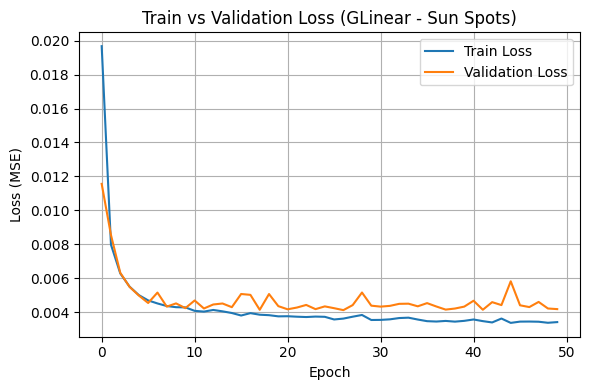

In [91]:
plt.figure(figsize=(6, 4))
plt.plot(train_losses_glinear_el_ss, label='Train Loss')
plt.plot(val_losses_glinear_el_ss, label='Validation Loss')
plt.title('Train vs Validation Loss (GLinear - Sun Spots)')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## Series data

In [44]:
def loader_to_series(loader):
    series = []
    for batch in loader:
        x, _ = batch
        series.append(x[:, :, 0])  # Get rid of feature dim (keep batch and seq_len)
    return torch.cat(series).flatten().numpy()


In [45]:
train_series_ss = loader_to_series(train_loader_ss)
val_series_ss = loader_to_series(val_loader_ss)
test_series_ss = loader_to_series(test_loader_ss)

train_series_el = loader_to_series(train_loader_el)
val_series_el = loader_to_series(val_loader_el)
test_series_el = loader_to_series(test_loader_el)


## Sarima

In [ ]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

In [ ]:
def sarima_objective(trial, train_series,val_series):
    p = trial.suggest_int("p", 0, 5)
    d = trial.suggest_int("d", 0, 2)
    q = trial.suggest_int("q", 0, 5)

    P = trial.suggest_int("P", 0, 5)
    D = trial.suggest_int("D", 0, 2)
    Q = trial.suggest_int("Q", 0, 5)
    s = 24

    try:
        model = SARIMAX(
            train_series,
            order=(p, d, q),
            seasonal_order=(P, D, Q, s),
            enforce_stationarity=False,
            enforce_invertibility=False
        )
        results = model.fit(disp=False)
        forecast = results.forecast(steps=len(val_series))
        return mean_squared_error(val_series, forecast)
    except:
        return float("inf")


In [ ]:
study_sarima_ss = optuna.create_study(direction="minimize")
study_sarima_ss.optimize(lambda trial: sarima_objective(trial, train_series_ss, val_series_ss), n_trials=10)

print("Best SARIMA params – Sunspot:")
print(study_sarima_ss.best_params)

In [ ]:
model_sarima_ss = SARIMAX(
    train_series_ss,
    order=(1, 0, 0),
    seasonal_order=(1, 1, 1, 24),
    enforce_stationarity=False,
    enforce_invertibility=False
)
results_ss = model_sarima_ss.fit()

forecast_ss = results_ss.forecast(steps=len(test_series_ss))

# Evaluate
mae_sarima_ss = mean_absolute_error(test_series_ss, forecast_ss)
mse_sarima_ss = mean_squared_error(test_series_ss, forecast_ss)
r2_sarima_ss = r2_score(test_series_ss, forecast_ss)

print("SARIMA – Sunspot:")
print(f"MAE: {mae_sarima_ss:.4f} | MSE: {mse_sarima_ss:.4f} | R²: {r2_sarima_ss:.4f}")

In [ ]:
model_sarima_ss_el = SARIMAX(
    train_series_el,
    order=(1, 0, 0),
    seasonal_order=(1, 1, 1, 24),
    enforce_stationarity=False,
    enforce_invertibility=False
)
results_ss_el = model_sarima_ss_el.fit()

forecast_ss_el = results_ss_el.forecast(steps=len(test_series_el))

# Evaluate
mae_sarima_ss_el = mean_absolute_error(test_series_el, forecast_ss_el)
mse_sarima_ss_el = mean_squared_error(test_series_el, forecast_ss_el)
r2_sarima_ss_el = r2_score(test_series_el, forecast_ss_el)

print("SARIMA – Electricity:")
print(f"MAE: {mae_sarima_ss_el:.4f} | MSE: {mse_sarima_ss_el:.4f} | R²: {r2_sarima_ss_el:.4f}")

## Arima

In [46]:
from statsmodels.tsa.arima.model import ARIMA


In [121]:
def arima_objective(trial, train_series, val_series):
    p = trial.suggest_int("p", 0, 5)
    d = trial.suggest_int("d", 0, 2)
    q = trial.suggest_int("q", 0, 5)

    try:
        model = ARIMA(train_series, order=(p, d, q))
        model_fit = model.fit()
        forecast = model_fit.forecast(steps=len(val_series))
        loss = mean_squared_error(val_series, forecast)
    except Exception as e:
        return float("inf")  # Skip failing models

    return loss

In [122]:
study_arima_ss = optuna.create_study(direction="minimize")
study_arima_ss.optimize(lambda trial: arima_objective(trial, train_series_ss, val_series_ss), n_trials=20)

print("Best ARIMA params – Sunspot:")
print(study_arima_ss.best_params)

[I 2025-04-21 16:59:40,359] A new study created in memory with name: no-name-5abcf727-daef-474c-a173-56cacd7365df
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
/usr/local/lib/python3.10/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
[I 2025-04-21 17:04:17,418] Trial 0 finished with value: 0.21972630432197052 and parameters: {'p': 2, 'd': 2, 'q': 4}. Best is trial 0 with value: 0.21972630432197052.
/usr/local/lib/python3.10/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
[I 2025-04-21 17:08:55,100] Trial 1 finishe

Best ARIMA params – Sunspot:
{'p': 4, 'd': 2, 'q': 1}


In [60]:
def test_arima(results, test_series):
    forecast = results.forecast(steps=len(test_series))
    
    # Evaluate
    mae = mean_absolute_error(test_series, forecast)
    mse = mean_squared_error(test_series, forecast)
    r2 = r2_score(test_series, forecast)
    return mae, mse, r2

In [54]:
def train_arima(model):
    results = model.fit()
    return results

In [53]:
model_arima_ss = ARIMA(
    train_series_ss,
    order=(0, 1, 4),
    enforce_stationarity=False,
    enforce_invertibility=False
)

In [55]:
%%time
result = train_arima(model_arima_ss)

CPU times: user 1min 2s, sys: 916 ms, total: 1min 3s
Wall time: 1min 3s


In [61]:
mae_arima_ss, mse_arima_ss, r2_arima_ss = test_arima(result, test_series_ss)

print("ARIMA – Sunspot:")
print(f"MAE: {mae_arima_ss:.4f} | MSE: {mse_arima_ss:.4f} | R²: {r2_arima_ss:.4f}")

ARIMA – Sunspot:
MAE: 0.1514 | MSE: 0.0302 | R²: -0.0553


In [62]:
model_arima_ss_el = ARIMA(
    train_series_el,
    order=(0, 1, 4),
    enforce_stationarity=False,
    enforce_invertibility=False
)

In [64]:
%%time
result_el = train_arima(model_arima_ss_el)

CPU times: user 19min 44s, sys: 10.2 s, total: 19min 54s
Wall time: 19min 52s


In [65]:
mae_arima_ss_el, mse_arima_ss_el, r2_arima_ss_el = test_arima(result_el, test_series_el)

print("ARIMA – Electricity:")
print(f"MAE: {mae_arima_ss_el:.4f} | MSE: {mse_arima_ss_el:.4f} | R²: {r2_arima_ss_el:.4f}")

ARIMA – Electricity:
MAE: 0.0955 | MSE: 0.0126 | R²: -0.0547


## N-Beats

In [12]:
class NBeatsBlock(nn.Module):
    def __init__(self, input_size, theta_size, hidden_size, num_layers):
        super().__init__()
        self.fc = nn.ModuleList([nn.Linear(input_size if i == 0 else hidden_size, hidden_size)
                                 for i in range(num_layers)])
        self.relu = nn.ReLU()
        self.theta_layer = nn.Linear(hidden_size, theta_size)

        self.backcast_size = input_size
        self.forecast_size = 1
        self.basis_function = self._trend_basis

    def forward(self, x):
        for layer in self.fc:
            x = self.relu(layer(x))
        theta = self.theta_layer(x)
        backcast, forecast = self.basis_function(theta)
        return backcast, forecast

    def _trend_basis(self, theta):
        p = 2  # polynomial degree 1 (theta has 2 params)
        t = torch.arange(self.backcast_size, dtype=torch.float32, device=theta.device) / self.backcast_size
        T = torch.stack([t ** i for i in range(p)], dim=0)  # [p, backcast]
        backcast = torch.matmul(theta[:, :p], T)  # [batch, backcast]
        forecast = theta[:, p:p+1]  # Just 1-step forecast (linear head)
        return backcast, forecast


In [13]:
class NBeats(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, num_blocks):
        super().__init__()
        self.blocks = nn.ModuleList([
            NBeatsBlock(input_size, theta_size=3, hidden_size=hidden_size, num_layers=num_layers)
            for _ in range(num_blocks)
        ])

    def forward(self, x):
        x = x.squeeze(-1)  # [batch, seq_len]
        backcast = x
        forecast = 0
        for block in self.blocks:
            b, f = block(backcast)
            backcast = backcast - b
            forecast = forecast + f
        return forecast  # [batch, 1, 1]

In [16]:
def nbeats_objective(trial, train_loader, val_loader):
    hidden_size = trial.suggest_int("hidden_size", 16, 128)
    num_layers = trial.suggest_int("num_layers", 1, 50)
    num_blocks = trial.suggest_int("num_blocks", 1, 10)
    lr = trial.suggest_float("lr", 1e-4, 1e-2, log=True)

    model = nn.DataParallel(NBeats(input_size=180, hidden_size=hidden_size,
                   num_layers=num_layers, num_blocks=num_blocks))

    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.MSELoss()

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)
    
    for epoch in range(10): 
        model.train()
        for x, y in train_loader:
            x, y = x.to(device), y.to(device)
            optimizer.zero_grad()
            output = model(x)
            loss = criterion(output, y.squeeze(-1))
            loss.backward()
            optimizer.step()


    model.eval()
    val_loss = 0
    with torch.no_grad():
        for x, y in val_loader:
            x, y = x.to(device), y.to(device)
            output = model(x)
            val_loss += criterion(output, y.squeeze(-1)).item()
    return val_loss / len(val_loader)


### Optimized for sun spot

In [147]:
study_nbeats_ss = optuna.create_study(direction="minimize")
study_nbeats_ss.optimize(lambda trial: nbeats_objective(trial, train_loader_ss, val_loader_ss), n_trials=20)

print("Best N-Beats params — Sunspot:")
print(study_nbeats_ss.best_params)

[I 2025-04-21 19:05:08,601] A new study created in memory with name: no-name-867df628-cfc4-44e2-8e15-d8485804ba0d
[I 2025-04-21 19:05:10,379] Trial 0 finished with value: 0.00441456341650337 and parameters: {'hidden_size': 89, 'num_layers': 4, 'num_blocks': 1, 'lr': 0.0004981194525774396}. Best is trial 0 with value: 0.00441456341650337.
[I 2025-04-21 19:05:16,101] Trial 1 finished with value: 0.00498968263855204 and parameters: {'hidden_size': 87, 'num_layers': 7, 'num_blocks': 4, 'lr': 0.001959135136127482}. Best is trial 0 with value: 0.00441456341650337.
[I 2025-04-21 19:05:26,279] Trial 2 finished with value: 0.051939085405319926 and parameters: {'hidden_size': 54, 'num_layers': 38, 'num_blocks': 2, 'lr': 0.0004906609089211166}. Best is trial 0 with value: 0.00441456341650337.
[I 2025-04-21 19:05:43,491] Trial 3 finished with value: 0.0055832728976383805 and parameters: {'hidden_size': 41, 'num_layers': 11, 'num_blocks': 10, 'lr': 0.001373887709232069}. Best is trial 0 with value:

Best N-Beats params — Sunspot:
{'hidden_size': 81, 'num_layers': 2, 'num_blocks': 1, 'lr': 0.0005780968766649794}


In [71]:
model_nbeats_ss = NBeats(input_size=180, hidden_size=81,
                   num_layers=2, num_blocks=1).to(device)
lr_nbeats_ss = 0.00057810

In [72]:
%%time
best_model_nbeats_ss, train_losses_nbeats_ss, val_losses_nbeats_ss, best_val_loss_nbeats_ss = train_model(model_nbeats_ss, train_loader_ss, val_loader_ss, lr=lr_nbeats_ss)

CPU times: user 8.24 s, sys: 156 ms, total: 8.39 s
Wall time: 8.67 s


In [73]:
mae_nbeats_ss, mse_nbeats_ss, r2_nbeats_ss = test_model(best_model_nbeats_ss, test_loader_ss)

MAE: 0.0400
MSE: 0.0028
R²: 0.8624


In [74]:
df_nbeats_ss = pd.DataFrame({'train_loss': train_losses_nbeats_ss, 'val_loss': val_losses_nbeats_ss})
df_nbeats_ss

,train_loss,val_loss
0,0.018986,0.010331
1,0.006920,0.007401
2,0.005189,0.005168
3,0.004591,0.005038
4,0.004326,0.005237
5,0.004428,0.004606
6,0.003985,0.004481
7,0.004110,0.005983
8,0.003985,0.004707
9,0.003751,0.005276


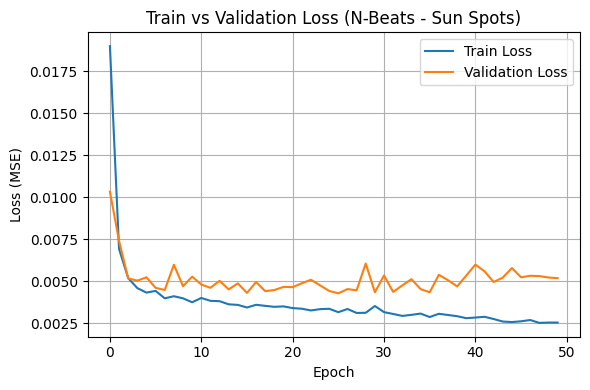

In [75]:
plt.figure(figsize=(6, 4))
plt.plot(train_losses_nbeats_ss, label='Train Loss')
plt.plot(val_losses_nbeats_ss, label='Validation Loss')
plt.title('Train vs Validation Loss (N-Beats - Sun Spots)')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [76]:
model_nbeats_ss_el = NBeats(input_size=180, hidden_size=81,
                   num_layers=2, num_blocks=1).to(device)

In [77]:
%%time
best_model_nbeats_ss_el, train_losses_nbeats_ss_el, val_losses_nbeats_ss_el, best_val_loss_nbeats_ss_el = train_model(model_nbeats_ss_el, train_loader_el, val_loader_el, lr=lr_nbeats_ss)

CPU times: user 1min 37s, sys: 1.77 s, total: 1min 39s
Wall time: 1min 40s


In [78]:
mae_nbeats_ss_el, mse_nbeats_ss_el, r2_nbeats_ss_el = test_model(best_model_nbeats_ss_el, test_loader_el)

MAE: 0.0587
MSE: 0.0073
R²: 0.3953


In [79]:
df_nbeats_ss_el = pd.DataFrame({'train_loss': train_losses_nbeats_ss_el, 'val_loss': val_losses_nbeats_ss_el})
df_nbeats_ss_el

,train_loss,val_loss
0,0.010511,0.007904
1,0.008325,0.008300
2,0.008077,0.009358
3,0.007885,0.007567
4,0.007773,0.007433
5,0.007637,0.007405
6,0.007490,0.008191
7,0.007323,0.007397
8,0.007231,0.007583
9,0.007052,0.007583


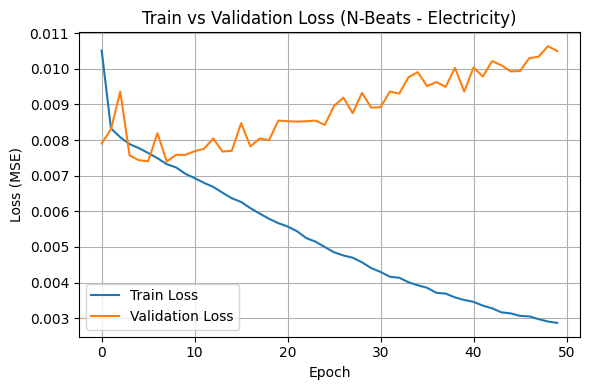

In [80]:
plt.figure(figsize=(6, 4))
plt.plot(train_losses_nbeats_ss_el, label='Train Loss')
plt.plot(val_losses_nbeats_ss_el, label='Validation Loss')
plt.title('Train vs Validation Loss (N-Beats - Electricity)')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

### Optimized for electricelectricity 

In [17]:
study_nbeats_el = optuna.create_study(direction="minimize")
study_nbeats_el.optimize(lambda trial: nbeats_objective(trial, train_loader_el, val_loader_el), n_trials=10)

[I 2025-04-24 06:47:39,357] A new study created in memory with name: no-name-b7be0601-9866-438e-aaca-fcdc7242c285
/usr/local/lib/python3.10/dist-packages/torch/nn/modules/linear.py:125: UserWarning: Attempting to run cuBLAS, but there was no current CUDA context! Attempting to set the primary context... (Triggered internally at ../aten/src/ATen/cuda/CublasHandlePool.cpp:135.)
  return F.linear(input, self.weight, self.bias)
[I 2025-04-24 06:53:13,444] Trial 0 finished with value: 0.007973488638248698 and parameters: {'hidden_size': 101, 'num_layers': 18, 'num_blocks': 6, 'lr': 0.00020004015815346083}. Best is trial 0 with value: 0.007973488638248698.
[I 2025-04-24 06:57:54,019] Trial 1 finished with value: 0.0196856676903405 and parameters: {'hidden_size': 118, 'num_layers': 50, 'num_blocks': 2, 'lr': 0.001946031272644637}. Best is trial 0 with value: 0.007973488638248698.
[I 2025-04-24 07:03:42,964] Trial 2 finished with value: 0.020091050983685407 and parameters: {'hidden_size': 86, 

Best N-Beats params — Electricty:


NameError: name 'study_nbeats_ss' is not defined

In [18]:
print("Best N-Beats params — Electricty:")
print(study_nbeats_el.best_params)

Best N-Beats params — Electricty:
{'hidden_size': 64, 'num_layers': 14, 'num_blocks': 5, 'lr': 0.00017224058681655451}


In [19]:
model_nbeats_el = NBeats(input_size=180, hidden_size=64,
                   num_layers=14, num_blocks=5).to(device)
lr_nbeats_el = 0.00017224

In [23]:
%%time
best_model_nbeats_el, train_losses_nbeats_el, val_losses_nbeats_el, best_val_loss_nbeats_el = train_model(model_nbeats_el, train_loader_el, val_loader_el, lr=lr_nbeats_el)

CPU times: user 10min 40s, sys: 1.51 s, total: 10min 41s
Wall time: 10min 43s


In [24]:
mae_nbeats_el, mse_nbeats_el, r2_nbeats_el = test_model(best_model_nbeats_el, test_loader_el)

MAE: 0.0636
MSE: 0.0085
R²: 0.2963


In [25]:
df_nbeats_el = pd.DataFrame({'train_loss': train_losses_nbeats_el, 'val_loss': val_losses_nbeats_el})
df_nbeats_el

,train_loss,val_loss
0,0.013072,0.008337
1,0.008388,0.007761
2,0.008057,0.007591
3,0.007770,0.007595
4,0.007590,0.007709
5,0.007417,0.007596
6,0.007224,0.007548
7,0.007163,0.007443
8,0.006944,0.007676
9,0.006756,0.007806


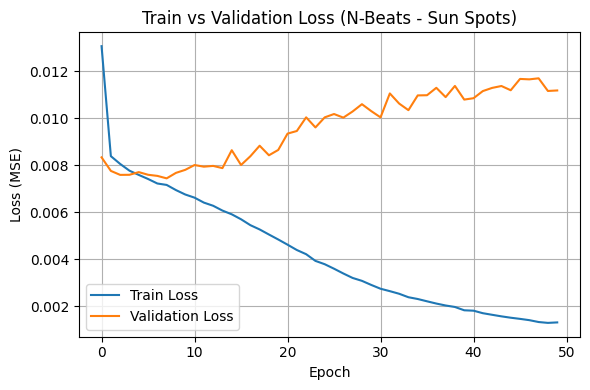

In [26]:
plt.figure(figsize=(6, 4))
plt.plot(train_losses_nbeats_el, label='Train Loss')
plt.plot(val_losses_nbeats_el, label='Validation Loss')
plt.title('Train vs Validation Loss (N-Beats - Sun Spots)')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [27]:
model_nbeats_el_ss = NBeats(input_size=180, hidden_size=64,
                   num_layers=14, num_blocks=5).to(device)

In [28]:
%%time
best_model_nbeats_el_ss, train_losses_nbeats_el_ss, val_losses_nbeats_el_ss, best_val_loss_nbeats_el_ss = train_model(model_nbeats_el_ss, train_loader_ss, val_loader_ss, lr=lr_nbeats_el)

CPU times: user 55.6 s, sys: 147 ms, total: 55.8 s
Wall time: 56 s


In [29]:
mae_nbeats_el_ss, mse_nbeats_el_ss, r2_nbeats_el_ss = test_model(best_model_nbeats_el_ss, test_loader_ss)

MAE: 0.0363
MSE: 0.0025
R²: 0.8760


In [30]:
df_nbeats_el_ss = pd.DataFrame({'train_loss': train_losses_nbeats_el_ss, 'val_loss': val_losses_nbeats_el_ss})
df_nbeats_el_ss

,train_loss,val_loss
0,0.094924,0.048532
1,0.026610,0.049397
2,0.018491,0.013537
3,0.009868,0.009345
4,0.007150,0.008071
5,0.005942,0.006004
6,0.005459,0.007272
7,0.004941,0.005489
8,0.004899,0.006081
9,0.004623,0.004833


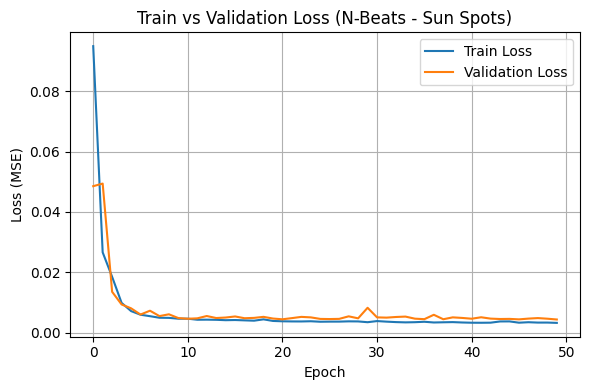

In [31]:
plt.figure(figsize=(6, 4))
plt.plot(train_losses_nbeats_el_ss, label='Train Loss')
plt.plot(val_losses_nbeats_el_ss, label='Validation Loss')
plt.title('Train vs Validation Loss (N-Beats - Sun Spots)')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()